# 1. 序論 (Introduction)

本章では、パターン認識と機械学習の基本的な概念について紹介します。
特に重要な実例として、**多項式曲線フィッティング (Polynomial Curve Fitting)** を取り上げ、過学習 (Overfitting) や正則化 (Regularization) といった概念を視覚的に理解します。

## 1.1 多項式曲線フィッティング

入力変数 $x$ から目的変数 $t$ を予測する回帰問題を考えます。
ここでは、真の関数を $t = \sin(2\pi x)$ とし、そこにガウスノイズが加わった人工データセットを使用します。

多項式モデルは以下のように定義されます。
$$ y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + ... + w_M x^M = \sum_{j=0}^{M} w_j x^j $$

誤差関数（二乗和誤差）は以下のようになります。
$$ E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} \{y(x_n, \mathbf{w}) - t_n\}^2 $$

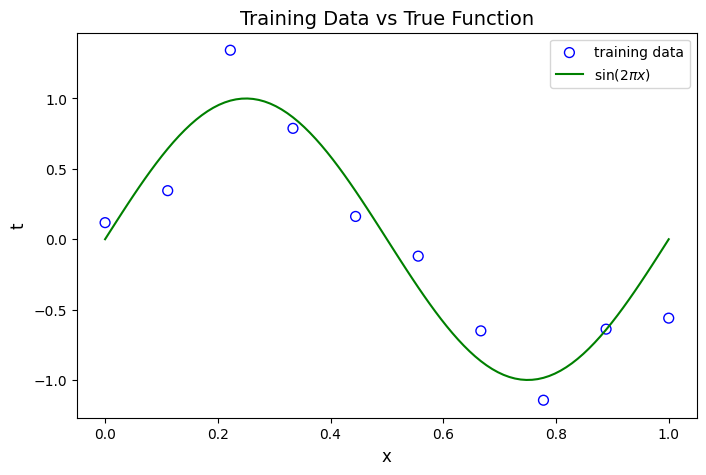

Plot saved to: result/fig1_2_training_data.png


In [1]:
import sys
import os
# commonディレクトリをパスに追加
sys.path.append(os.path.abspath('../../'))

import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style

# スタイルのセットアップ
setup_style()

# データの生成関数
def create_toy_data(func, sample_size, std):
    x = np.linspace(0, 1, sample_size)
    t = func(x) + np.random.normal(scale=std, size=x.shape)
    return x, t

def func(x):
    return np.sin(2 * np.pi * x)

# 訓練用データ (N=10)
np.random.seed(1234)
x_train, t_train = create_toy_data(func, 10, 0.25)

# 描画用の真の関数とテストデータ
x_test = np.linspace(0, 1, 100)
t_test = func(x_test)

fig = plt.figure(figsize=(8, 5))
plt.scatter(x_train, t_train, facecolor='none', edgecolor='b', s=50, label='training data')
plt.plot(x_test, t_test, c='g', label='$\sin(2\pi x)$')
plt.legend()
plt.xlabel('x')
plt.ylabel('t')
plt.title('Training Data vs True Function')
plt.show()

# グラフをresultディレクトリに保存
save_plot(fig, 'result', 'fig1_2_training_data.png')


### 多項式フィッティングの実行

階数 $M$ を変化させたときのフィッティング曲線の振る舞いを確認します。
$M$ が小さすぎる（例えば $M=0, 1$）とモデルが単純すぎてデータを表現できず（未学習）、逆に $M$ が大きすぎる（例えば $M=9$）とデータ点のノイズまで完全に学習してしまいます（過学習）。

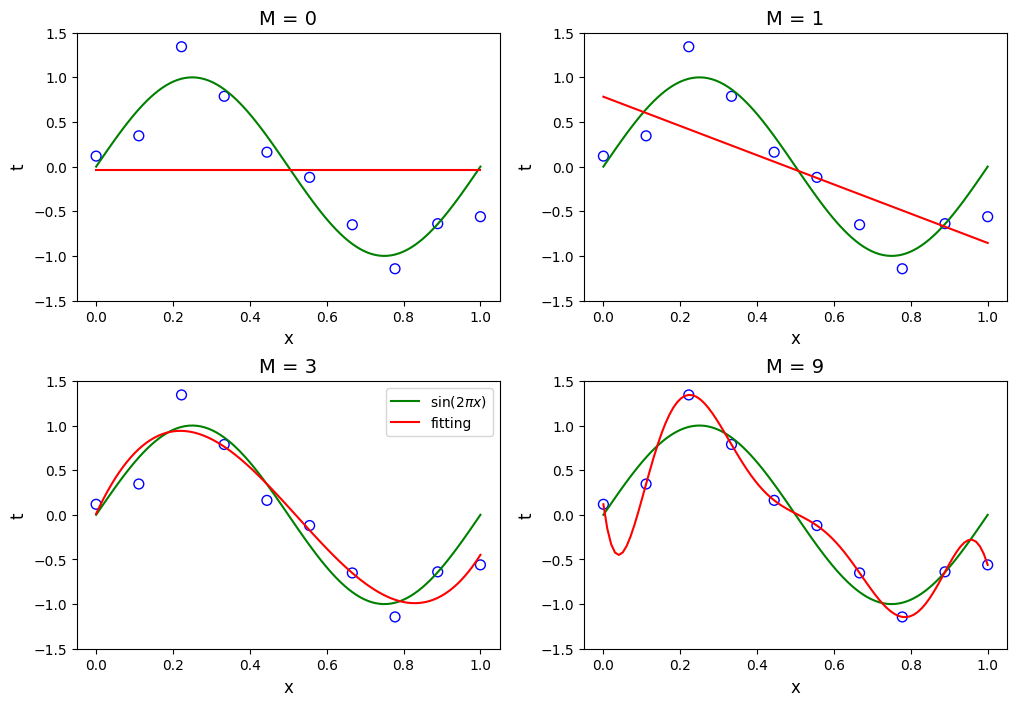

Plot saved to: result/fig1_4_poly_fitting_M.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.subplots_adjust(hspace=0.3)

degrees = [0, 1, 3, 9]

for ax, degree in zip(axes.ravel(), degrees):
    # 多項式フィッティング
    poly = np.polyfit(x_train, t_train, degree)
    poly_func = np.poly1d(poly)
    
    ax.scatter(x_train, t_train, facecolor='none', edgecolor='b', s=50)
    ax.plot(x_test, t_test, c='g', label='$\sin(2\pi x)$')
    ax.plot(x_test, poly_func(x_test), c='r', label='fitting')
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'M = {degree}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    if degree == 3:
        ax.legend()

plt.show()
save_plot(fig, 'result', 'fig1_4_poly_fitting_M.png')


### 1.1.1 汎化性能の評価 (RMS Error)

モデルの良さを定量的に測るため、二乗平方根誤差（Root-Mean-Square Error, $E_{RMS}$）を計算します。
$$ E_{RMS} = \sqrt{2 E(\mathbf{w}^*) / N} $$

$M$ が増加するにつれて、訓練誤差は減少しますが、テスト誤差はある点から増加に転じます（過学習の典型的なサインです）。

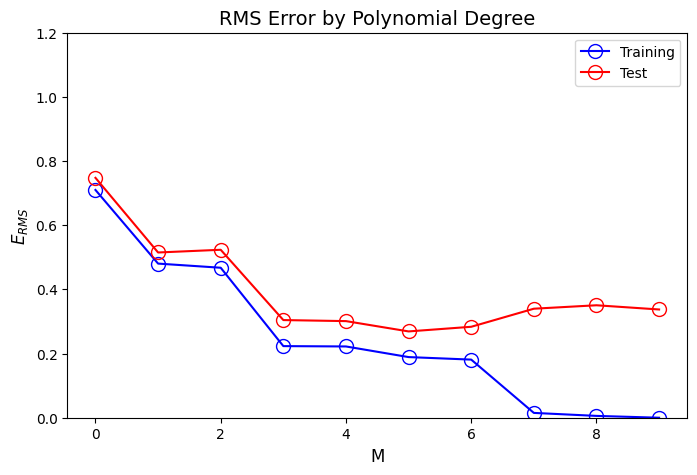

Plot saved to: result/fig1_5_rms_error.png


In [3]:
# テスト用のデータ生成 (N=100)
x_test_pts, t_test_pts = create_toy_data(func, 100, 0.25)

def rmse(a, b):
    return np.sqrt(np.mean(np.square(a - b)))

training_errors = []
test_errors = []

for i in range(10):
    poly = np.polyfit(x_train, t_train, i)
    poly_func = np.poly1d(poly)
    
    training_errors.append(rmse(poly_func(x_train), t_train))
    test_errors.append(rmse(poly_func(x_test_pts), t_test_pts))

fig = plt.figure(figsize=(8, 5))
plt.plot(range(10), training_errors, 'o-', mfc='none', mec='b', ms=10, c='b', label='Training')
plt.plot(range(10), test_errors, 'o-', mfc='none', mec='r', ms=10, c='r', label='Test')
plt.legend()
plt.xlabel('M')
plt.ylabel('$E_{RMS}$')
plt.title('RMS Error by Polynomial Degree')
plt.ylim(0, 1.2)
plt.show()
save_plot(fig, 'result', 'fig1_5_rms_error.png')


### 1.1.2 正則化 (Regularization)

過学習を防ぐ手法の一つとして、誤差関数にペナルティ項を加える正則化があります。代表的なものが重みの二乗和を用いるL2正則化です（Ridge回帰とも呼ばれます）。
$$ \tilde{E}(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} \{y(x_n, \mathbf{w}) - t_n\}^2 + \frac{\lambda}{2} \|\mathbf{w}\|^2 $$

これにより、モデルが複雑になる（係数 $\mathbf{w}$ が極端に大きくなる）ことを抑制します。

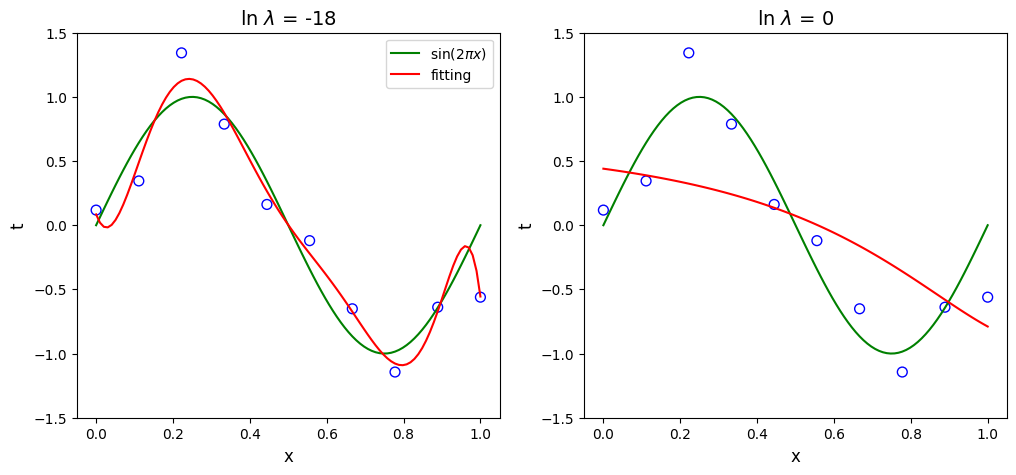

Plot saved to: result/fig1_7_regularization.png


In [4]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

def fit_regularized(degree, alpha):
    # 多項式特徴量の生成
    poly = PolynomialFeatures(degree=degree)
    X_train = poly.fit_transform(x_train.reshape(-1, 1))
    X_test = poly.transform(x_test.reshape(-1, 1))
    
    # 正則化付き線形回帰 (Ridge回帰)
    model = Ridge(alpha=alpha)
    model.fit(X_train, t_train)
    
    return model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

alphas = [np.exp(-18), np.exp(0)] # ln lambda = -18, 0

for ax, alpha in zip(axes, alphas):
    y_pred = fit_regularized(degree=9, alpha=alpha)
    
    ax.scatter(x_train, t_train, facecolor='none', edgecolor='b', s=50)
    ax.plot(x_test, t_test, c='g', label='$\sin(2\pi x)$')
    ax.plot(x_test, y_pred, c='r', label='fitting')
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'ln $\lambda$ = {np.log(alpha):.0f}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    if alpha == np.exp(-18):
        ax.legend()

plt.show()
save_plot(fig, 'result', 'fig1_7_regularization.png')
